In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---------- P1: Load, Clean & Merge ----------
deliveries = pd.read_csv("deliveries.csv")
routes = pd.read_csv("routes.csv")

In [7]:
deliveries["actual_days"] = (
    deliveries["actual_days"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)

print(deliveries[["promised_days", "actual_days"]].dtypes)

promised_days    int64
actual_days      int64
dtype: object


In [8]:
deliveries = deliveries.drop_duplicates()
print("rows after drop_duplicates:", len(deliveries))

rows after drop_duplicates: 12


In [9]:
df = deliveries.merge(routes, on="route_id", how="left")
df

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


In [10]:
assert len(df) == 12
assert df["service_type"].isna().sum() == 0
print("All checks passed")

All checks passed


In [11]:
df.shape

(12, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   record_id      12 non-null     int64
 1   month          12 non-null     str  
 2   route_id       12 non-null     str  
 3   hub            12 non-null     str  
 4   promised_days  12 non-null     int64
 5   actual_days    12 non-null     int64
 6   route          12 non-null     str  
 7   service_type   12 non-null     str  
dtypes: int64(3), str(5)
memory usage: 900.0 bytes


In [13]:
df.head()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express


In [14]:
df.tail()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express
10,11,Mar,R3,Chennai,5,5,Highway Freight,Standard
11,12,Mar,R4,Mumbai,6,15,Rural Feeder,Standard


In [15]:
df.describe()

,record_id,promised_days,actual_days
count,12.000000,12.000000,12.000000
mean,6.500000,4.000000,6.833333
std,3.605551,1.651446,3.639014
min,1.000000,2.000000,2.000000
25%,3.750000,2.750000,4.750000
50%,6.500000,4.000000,6.000000
75%,9.250000,5.250000,8.500000
max,12.000000,6.000000,15.000000


In [16]:
df.columns

Index(['record_id', 'month', 'route_id', 'hub', 'promised_days', 'actual_days',
       'route', 'service_type'],
      dtype='str')

In [17]:
# ---------- P2: Derived field & service-type analysis ----------
df["delay_days"] = (df["actual_days"] - df["promised_days"]).clip(lower=0)


In [18]:
df["is_delayed"] = df["actual_days"] > df["promised_days"]
summary = df.groupby("service_type").agg(
    total_delay_days=("delay_days", "sum"),
    delay_incidence_rate=("is_delayed", lambda x: x.mean() * 100)
).reset_index()
print(summary)

  service_type  total_delay_days  delay_incidence_rate
0      Express                12             66.666667
1     Standard                22             83.333333


In [19]:
route_delay = df.groupby("route")["delay_days"].sum()
top_route = route_delay.idxmax()
total = df["delay_days"].sum()
print("Top route:", top_route)
print("Summed delay_days:", route_delay.max())
print("Share of overall total:", round(route_delay.max() / total * 100, 2), "%")

Top route: Rural Feeder
Summed delay_days: 14
Share of overall total: 41.18 %


In [20]:
# ---------- P3: Chart & Exports ----------
os.makedirs("outputs", exist_ok=True)


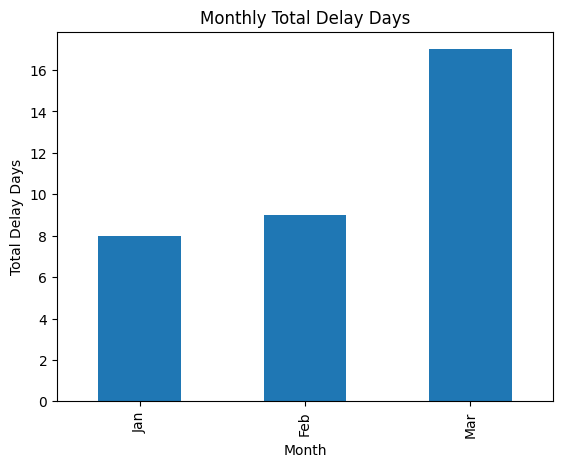

In [21]:
monthly = df.groupby("month")["delay_days"].sum().reindex(["Jan", "Feb", "Mar"])
monthly.plot(kind="bar")
plt.title("Monthly Total Delay Days")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")
plt.savefig("outputs/python_chart.png")

In [22]:
df.drop(columns="is_delayed").to_csv("outputs/clean_data.csv", index=False)
summary.to_csv("outputs/python_summary.csv", index=False)